# Graphics updates: tasks #5, #6, #8, #9

Demo notebook for four items from `team/symbulate-graphics-tasklist.md`, run
against the `feature/bins-marginal-fixes` branch. Each section just shows the
behavior -- see `DECISIONS.md` for the full rationale behind each choice.

In [1]:
from symbulate import *
import numpy as np

## #5 -- Histogram binning: explored, then reverted to the flat default

`RV(F(5,4)).sim(10000)` is heavily right-skewed: 99% of the mass sits below
~16, but the max can be 100+ from rare draws. Earlier in this work an
outlier/skew-aware binning scheme (first a Tukey-fence + overflow bar, then a
full-range Freedman-Diaconis bin *count*) was implemented for exactly this
case. The team reviewed it and decided against a dynamic bin count for
`make_hist` altogether -- see `DECISIONS.md`,
"Outlier/Skew-Aware Histogram Binning -- Reverted to Flat 30 Bins". `bins=None`
is once again simply `HIST_DEFAULT_BINS` (30) equal-width bins over the full
raw range, unconditionally -- exactly the pre-session behavior.

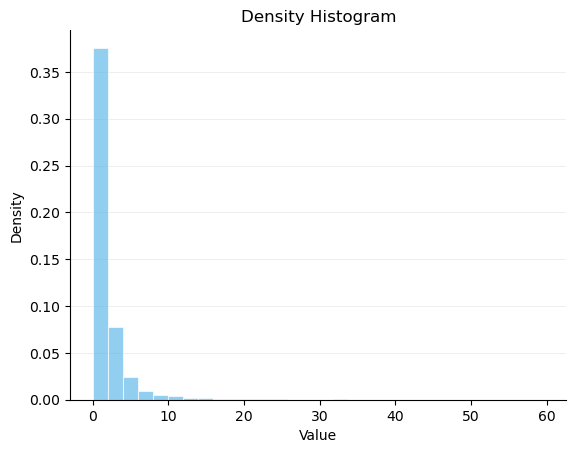

In [2]:
np.random.seed(0)
RV(F(5, 4)).sim(10000).plot(suggest=False)

With a flat 30 bins over the true min-to-max range, the bulk of this
distribution's shape (below ~16) is crushed into just a couple of bars next
to a long near-empty stretch out to the rare large draws. That's the known,
accepted tradeoff of the flat-bin default -- not a bug introduced by this
session's work, and not something this default is trying to solve; a
skew-aware binning scheme may be revisited later, but is not part of the
current release.

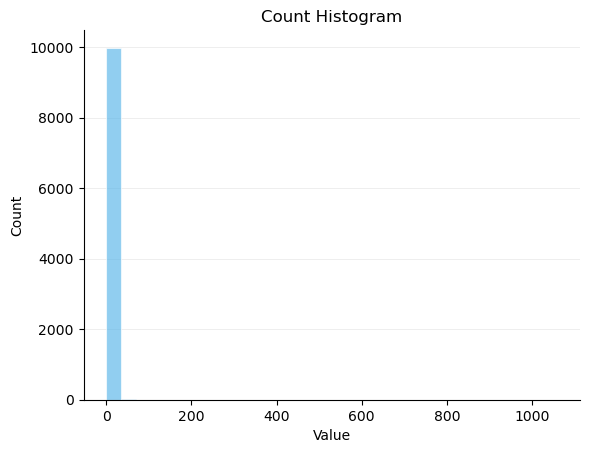

In [3]:
# normalize=False: raw counts, same flat 30-bin scheme.
np.random.seed(0)
RV(F(5, 4)).sim(10000).plot(normalize=False, suggest=False)

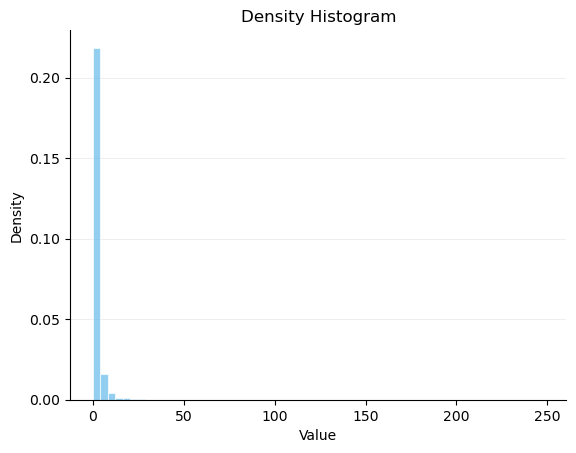

In [4]:
# An explicit bins= always wins outright -- exactly that many equal-width
# bins over the full range. This was true before, during, and after every
# binning experiment this session tried -- untouched throughout.
np.random.seed(0)
RV(F(5, 4)).sim(10000).plot(bins=60, suggest=False)

## #6 -- Discreteness thresholds are independent of the histogram's bin count

Task 6 was verification, not a code change: confirm `B_1D`/`K_2D` (the
discrete-vs-continuous budget) never actually depend on `make_hist`'s bin
count, and document it in `DECISIONS.md`. This held even while #5's
adaptive scheme was briefly live -- e.g. `RV(F(5, 4)).sim(10000)` got
**1185** adaptive bins and `RV(Normal(0, 1)).sim(2000)` got **31** (seed 0
for both), while `B_1D`/`K_2D` stayed fixed at 30 the whole time. Now that
#5 is fully reverted to flat 30 (see above), the question is moot again --
but `classify_values` never read `make_hist`'s bin count in the first
place, dynamic or not.

In [5]:
from symbulate.plot import (
    B_1D, K_2D, HIST_DEFAULT_BINS, HIST2D_DEFAULT_BINS, TILE_DEFAULT_BINS,
)

print("B_1D  (1D discreteness budget):  ", B_1D)
print("K_2D  (2D discreteness budget):  ", K_2D)
print("HIST_DEFAULT_BINS  (make_hist's only bin count, flat, always):", HIST_DEFAULT_BINS)
print("HIST2D_DEFAULT_BINS (make_hist2d):", HIST2D_DEFAULT_BINS)
print("TILE_DEFAULT_BINS   (make_tile):  ", TILE_DEFAULT_BINS)

B_1D  (1D discreteness budget):   30
K_2D  (2D discreteness budget):   30
HIST_DEFAULT_BINS  (make_hist's only bin count, flat, always): 30
HIST2D_DEFAULT_BINS (make_hist2d): 30
TILE_DEFAULT_BINS   (make_tile):   30


All three default bin counts are independent, flat `= 30` constants:

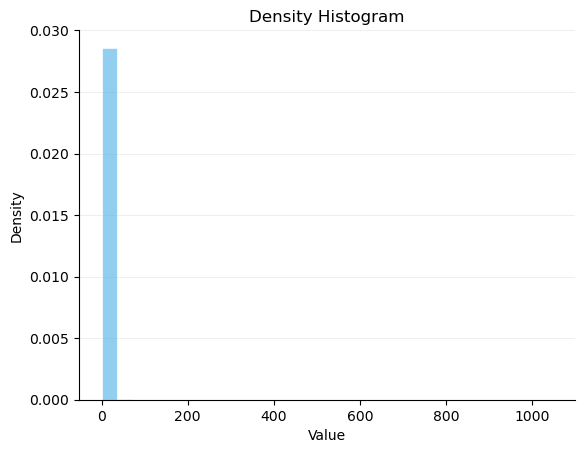

In [6]:
# 1D: flat 30-bin scheme (see #5 above).
np.random.seed(0)
RV(F(5, 4)).sim(10000).plot(type="hist", suggest=False)

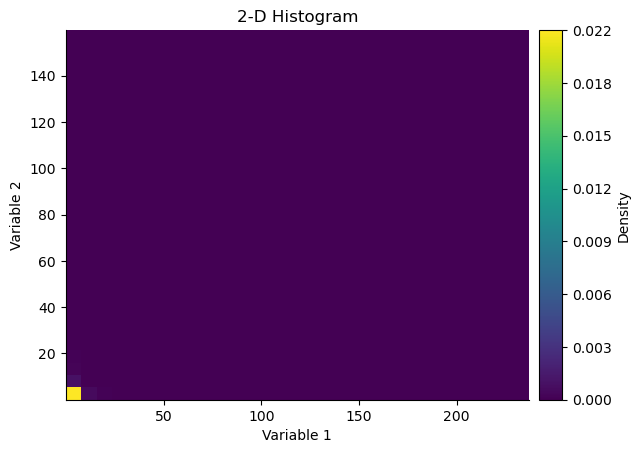

In [7]:
# 2D histogram: flat 30-bin scheme -- the same skewed variable crossed
# with itself crushes into a corner, same as the 1D case above.
np.random.seed(0)
X, Y = RV(F(5, 4) ** 2)
(X & Y).sim(10000).plot(type="hist2d", suggest=False)

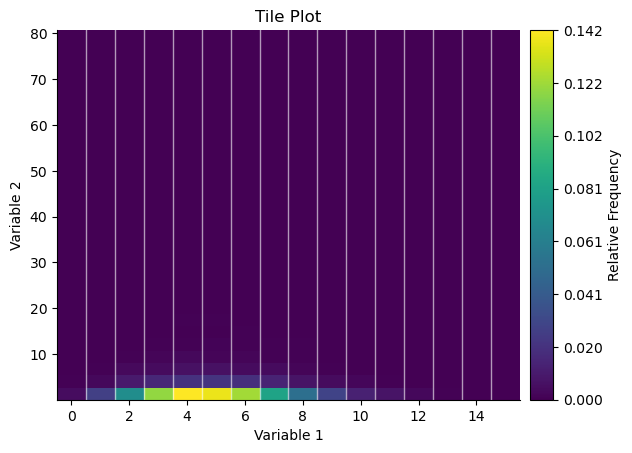

In [8]:
# Tile's continuous axis: same flat 30-bin scheme -- a skewed continuous
# axis crossed with a discrete one crushes the same way (a separate,
# not-yet-tackled problem, unrelated to #5's now-reverted experiment).
np.random.seed(0)
X, Y = RV(Poisson(lam=5) * F(5, 4))
(X & Y).sim(10000).plot(type="tile", suggest=False)

The sharpest check: a distribution sitting right at the `B_1D = 30`
boundary.

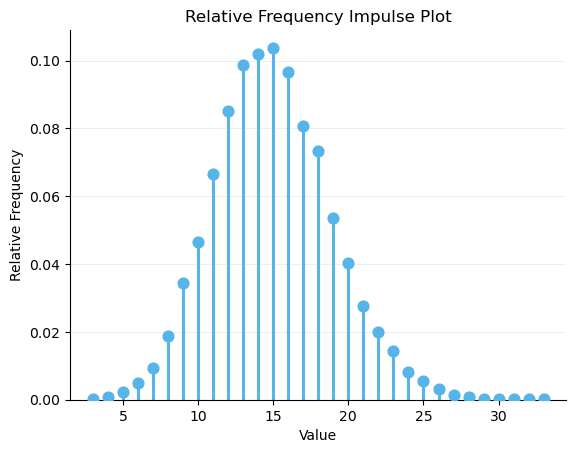

In [9]:
# Poisson(15) realizes ~30 distinct values at n=10000 -- right at the B_1D
# edge. It still reads as discrete (an impulse plot, not a histogram) --
# classify_values never looks at make_hist's bin count at all.
np.random.seed(0)
RV(Poisson(15)).sim(10000).plot(suggest=False)

## #8 -- Marginal panel rebuild (real helpers + coordinate alignment)

Marginal panels (`marginal=True`) used to run through legacy, pre-redesign
code and could visually misalign with the main panel. Confirmed case:
`DiscreteUniform(50,60)` starts at 50, but tile's discrete axis used to plot
at compressed index positions (0-10) while the marginal plotted at real
values (50-60) -- two different scales stacked in one figure.

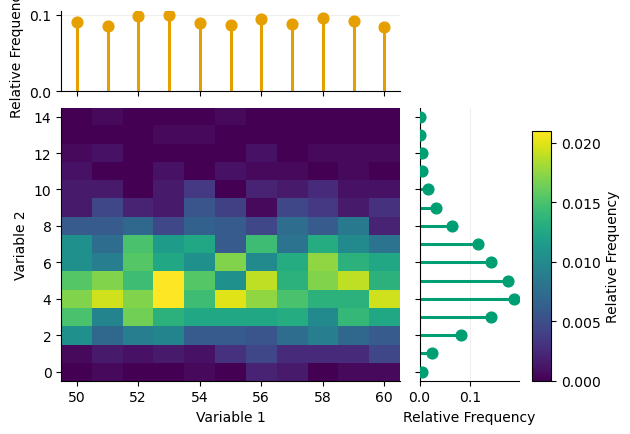

In [10]:
np.random.seed(0)
X, Y = RV(DiscreteUniform(a=50, b=60) * Poisson(lam=5))
(X & Y).sim(2000).plot(type="tile", marginal=True, suggest=False)

Main panel and marginals now share exactly the same scale on both axes.

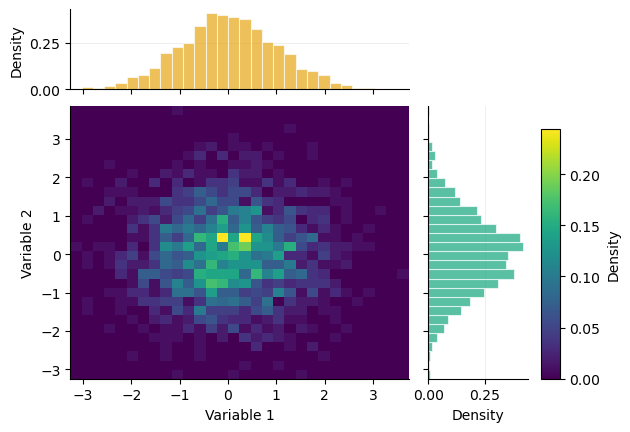

In [11]:
# hist2d + marginal: continuous x continuous, large n.
np.random.seed(0)
X, Y = RV(Normal(0, 1) ** 2)
(X & Y).sim(2000).plot(type="hist2d", marginal=True, suggest=False)

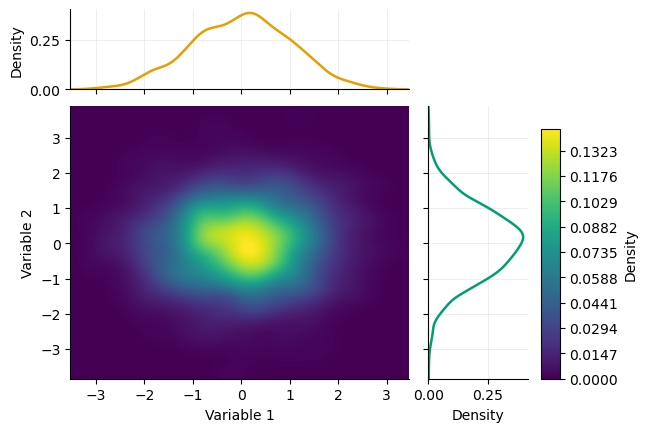

In [12]:
# density2d + marginal: when the main panel is a density surface, both
# marginals draw density curves too -- not impulse/hist -- matching the
# main panel's own representation.
np.random.seed(0)
X, Y = RV(Normal(0, 1) ** 2)
(X & Y).sim(2000).plot(type="density2d", marginal=True, suggest=False)

Marginal type is now routed through `classify_values` per axis, just like a
standalone 1D variable would be -- not hardcoded to impulse-or-hist regardless
of sample size.

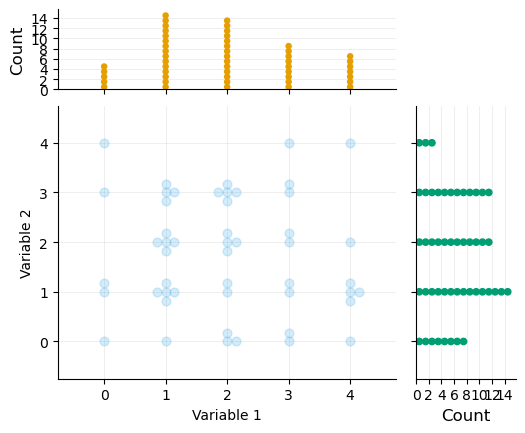

In [13]:
# Small-n discrete x discrete: dot-plot marginals, not impulse.
np.random.seed(0)
X, Y = RV(Binomial(5, 0.4) ** 2)
(X & Y).sim(50).plot(type="scatter", marginal=True, suggest=False)

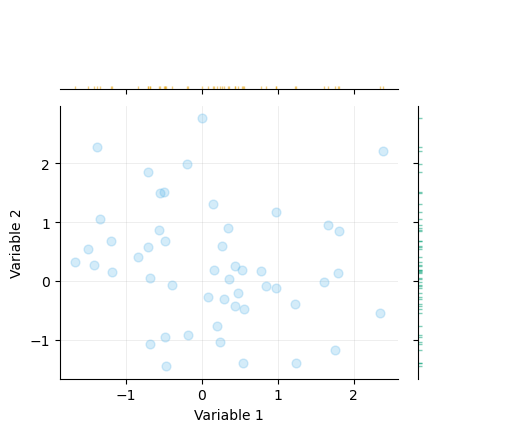

In [14]:
# Small-n continuous x continuous: rug marginals.
np.random.seed(0)
X, Y = RV(Normal(0, 1) ** 2)
(X & Y).sim(50).plot(type="scatter", marginal=True, suggest=False)

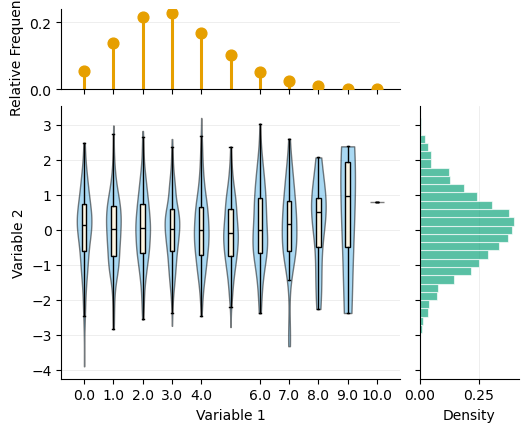

In [15]:
# Mixed data (one discrete axis, one continuous) works too -- here with violin.
np.random.seed(0)
X, Y = RV(Poisson(lam=3) * Normal(0, 1))
(X & Y).sim(2000).plot(type="violin", marginal=True, suggest=False)

`mosaic` is the one deliberate exception: it already shows x's marginal via
column width and y's marginal via its own optional side column, so a second,
generic marginal mechanism would just be redundant. `marginal=True` with
`type="mosaic"` raises a friendly error pointing at that existing feature
instead of drawing a duplicate.

In [16]:
try:
    X, Y = RV(Binomial(5, 0.4) ** 2)
    (X & Y).sim(500).plot(type="mosaic", marginal=True)
except ValueError as e:
    print(e)

marginal=True isn't supported with type='mosaic' -- a mosaic plot already shows x's marginal distribution through its column widths and y's marginal distribution through its own marginal column. Use type='mosaic', marginal_column=True (the default) instead of marginal=True.


## #9 -- `marginal=True` instead of `type=[..., "marginal"]`

`marginal` used to be a string smuggled into the `type=` list, which was
inconsistent with every other modifier (`bins=`, `jitter=`) already being a
real keyword. It's now its own `marginal=True/False` argument.

In [17]:
# The old spelling is no longer valid -- it raises, and points at the fix.
try:
    X, Y = RV(Normal(0, 1) ** 2)
    (X & Y).sim(500).plot(type=["hist", "marginal"])
except ValueError as e:
    print(e)

'marginal' is no longer a type= value -- it's now its own keyword argument. Use marginal=True instead, e.g. .plot(type='hist', marginal=True).


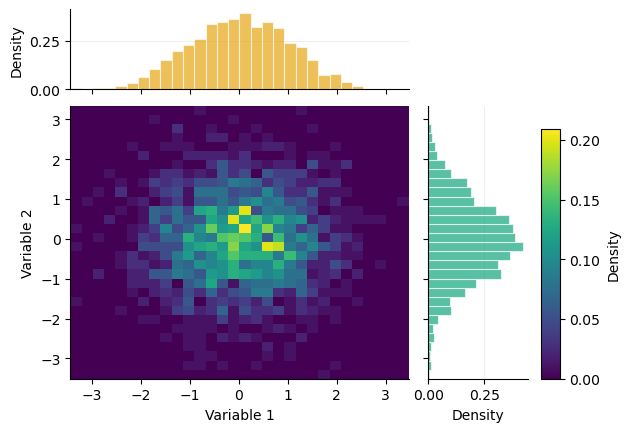

In [18]:
# The new spelling: marginal is its own argument, combined with type= as usual.
np.random.seed(0)
X, Y = RV(Normal(0, 1) ** 2)
(X & Y).sim(2000).plot(type="hist", marginal=True, suggest=False)